# Experiment pipeline 2 (module demo)

This notebook reproduces the **Experiment pipeline 2** section from `notebooks/MaxInfo.ipynb`, but uses `maxinfo` as an imported module (no inline implementation code).


## Install (editable)

Run this once in a terminal (recommended):

```bash
uv venv
uv sync
```



In [1]:
import maxinfo

print('maxinfo imported:', maxinfo.__name__)

maxinfo imported: maxinfo


🚀 Starting MaxInfo pipeline
   Video: ../data/lecture_14_ml.mp4
   FPS sample: 1.0, Max candidates: 256
   Segment: 0s - 60s


c:\Users\yazan\OneDrive\Desktop\MaxInfo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 Loading CLIP model: openai/clip-vit-large-patch14-336...


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 826.13it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded: openai/clip-vit-large-patch14-336
📦 Loading processor: openai/clip-vit-large-patch14-336...
✓ Processor loaded
📹 Loading video candidates (fps=1.0, max=256)...
✓ Loaded 60 frames from video
📊 Running uniform selection (budget=8)...
✓ Uniform selected 8 frames
🎯 Running MaxInfo selection...
🎯 MaxInfo selection: 60 frames → budget=8, rank=6, tol=0.3


🔍 Extracting CLIP features: 100%|██████████| 4/4 [01:22<00:00, 20.71s/it]


📐 Running SVD (rank=6)...
✓ SVD complete: Qs shape = (60, 6)
📊 Running MaxVol greedy selection (tol=0.3, n=60, r=6)...
✓ Selected 39 pivots from 60 candidates
📉 Subsampling from 39 to 8 pivots...
✓ MaxInfo selection complete: 8 frames selected
✅ Pipeline complete!
   Uniform: 8 frames
   MaxInfo: 8 frames


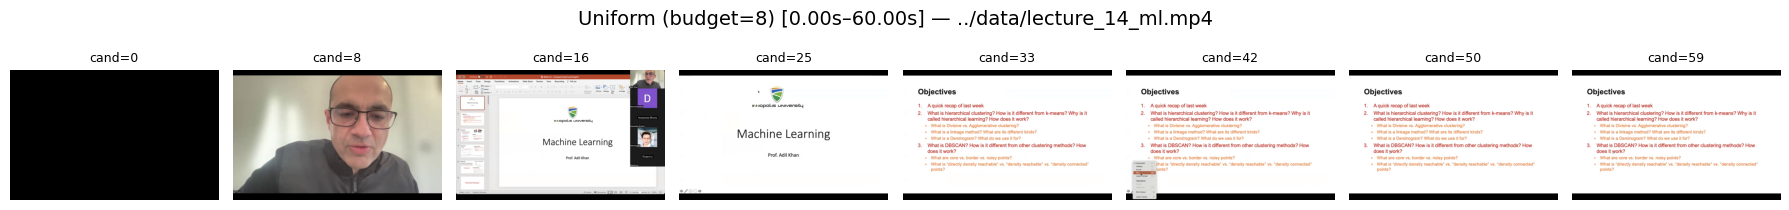

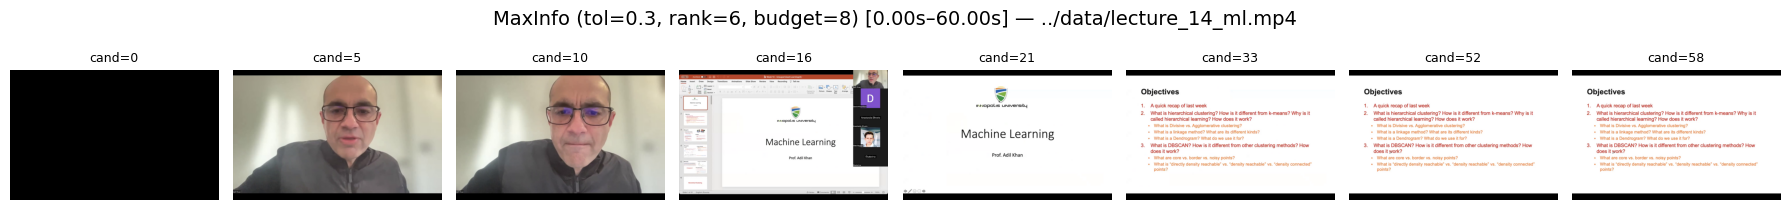

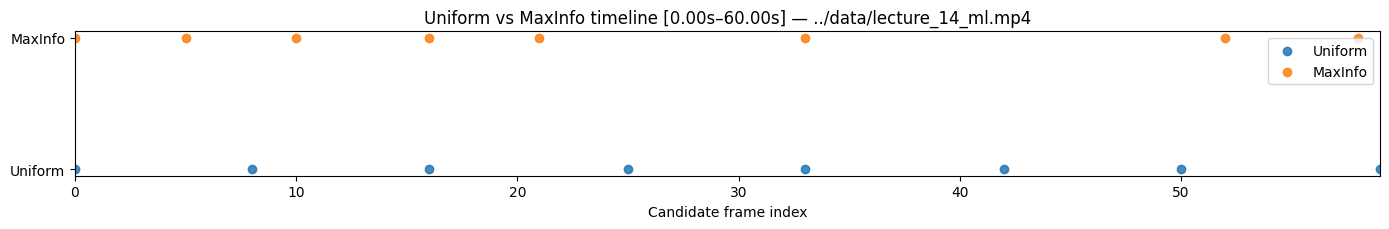

Uniform indices: [0, 8, 16, 25, 33, 42, 50, 59]
MaxInfo indices: [0, 5, 10, 16, 21, 33, 52, 58]


In [2]:
# Edit this path to point to your video
video_path = r"../data/lecture_14_ml.mp4"

# Optional: restrict to a segment
start_sec = 0  # e.g. 10*60
end_sec = 60    # e.g. 20*60

out = maxinfo.compare_sampling_on_video(
    video_path=video_path,
    choose_fps=1.0,
    max_candidates=256,
    budget=8,
    svd_rank=6,
    tol=0.3,
    batch_size=16,
    start_sec=start_sec,
    end_sec=end_sec,
    show=True,
)

print('Uniform indices:', out['uniform']['indices'])
print('MaxInfo indices:', out['maxinfo']['indices'])